In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import KFold, cross_validate, permutation_test_score, cross_val_predict
from sklearn.metrics import (
    r2_score, mean_absolute_error, mean_squared_error,
    make_scorer
)
from sklearn.inspection import permutation_importance

In [2]:
# -------------------------------------------------------------------
# Load feature matrix
# -------------------------------------------------------------------
base = "/Users/ivanatang/Library/CloudStorage/OneDrive-UCB-O365/Shirts Lab/LCA_boltz_models"
df = pd.read_excel(os.path.join(base, "feat_table.xlsx"), sheet_name="all_feats_new", index_col="ID")

df_reg = df.copy()
# df_reg.loc[df_reg["Group"] != "binder", "Binder_score"] = 0.0
df_reg = df[df["Group"] == "binder"].dropna(subset=["Binder_score"]).copy()

n_total    = len(df_reg)
n_binders  = (df_reg["Group"] == "binder").sum()
n_nonbinders = n_total - n_binders

print(f"Total samples after cleaning : {n_total}")
print(f"  Binders (with score)        : {n_binders}")
print(f"  Nonbinders (score = 0)      : {n_nonbinders}")
print(f"  Dropped binders (NaN score) : {(df['Group']=='binder').sum() - n_binders}")
print()
print("Group breakdown:")
print(df_reg["Group"].value_counts().to_string())
print()
print("Binder_score summary (binders only):")
print(df_reg.loc[df_reg["Group"]=="binder", "Binder_score"].describe().round(4).to_string())

Total samples after cleaning : 31
  Binders (with score)        : 31
  Nonbinders (score = 0)      : 0
  Dropped binders (NaN score) : 6

Group breakdown:
Group
binder    31

Binder_score summary (binders only):
count    31.0000
mean      0.6692
std       0.2202
min       0.2222
25%       0.5794
50%       0.6604
75%       0.7687
max       1.4118


In [3]:
# -------------------------------------------------------------------
# Feature columns
# -------------------------------------------------------------------
# feature_cols = [
#     "Gate mean (A)",       "Gate SD (A)",
#     "Latch mean (A)",      "Latch SD (A)",
#     "Lb7a5 mean (A)",      "Lb7a5 SD (A)",
#     "Recoil mean (A)",     "Recoil SD (A)",
#     "Gate-latch mean (A)", "Gate-latch SD (A)",
#     "Closed % (<9.5 A)",   "Open % (>11.5 A)", "Intermediate %",
#     "R_58", "R_59", "R_62",	"R_83",	"R_87",	"R_88",	"R_89",	"R_92",	"R_110", "R_115", "R_116", "R_117", "R_120", "R_122", "R_159",
#     "R_160", "R_163","R_164"
# ]

feature_cols = [
    "Gate mean (A)", "Gate SD (A)",
    "Intermediate %",
    "R_62", "R_163", "R_164", "R_122", "R_83", "R_89", "R_87", "R_159", "R_160", "R_59", "R_116", "R_115", "R_58", 
    "Lb7a5 mean (A)"
]

X = df_reg[feature_cols].values
y = df_reg["Binder_score"].values

print(f"Feature matrix shape: {X.shape}")
print(f"Target range: [{y.min():.3f}, {y.max():.3f}]  |  mean: {y.mean():.3f}  |  std: {y.std():.3f}")

Feature matrix shape: (31, 17)
Target range: [0.222, 1.412]  |  mean: 0.669  |  std: 0.217


/var/folders/b1/77x_k7v964g1hhhp9pz24yr40000gn/T/ipykernel_1544/2264166051.py:33: RuntimeWarning: Mean of empty slice.
  ax2.plot([i - 0.3, i + 0.3], [scores.mean(), scores.mean()],
/Users/ivanatang/miniforge3/envs/openff-toolkit/lib/python3.13/site-packages/numpy/_core/_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


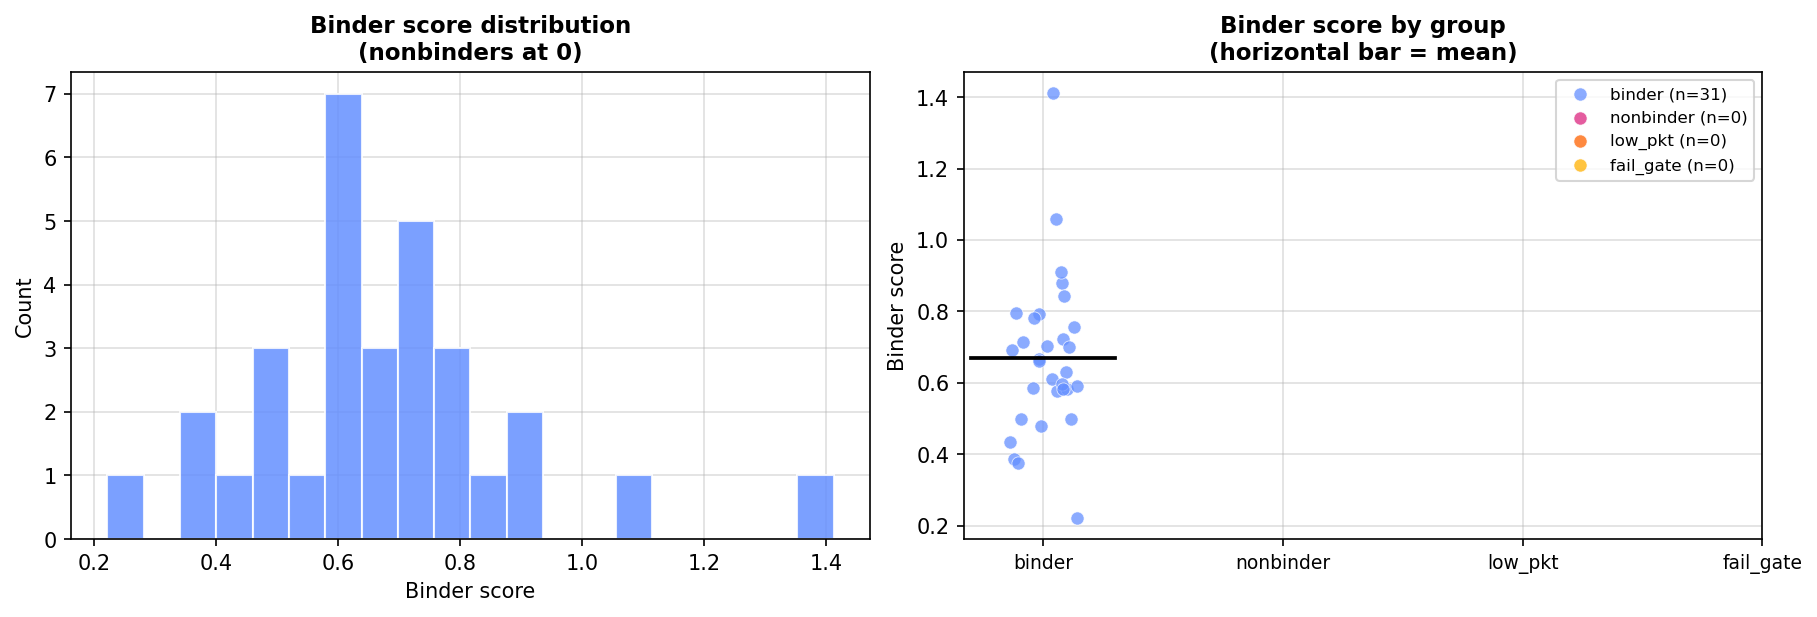

In [4]:
# -------------------------------------------------------------------
# Visualise target distribution before modelling
# -------------------------------------------------------------------
GROUP_COLORS = {
    "binder":     "#648FFF",
    "nonbinder":  "#DC267F",
    "low_pkt":    "#FE6100",
    "fail_gate":  "#FFB000",
}

fig, axes = plt.subplots(1, 2, figsize=(12, 4), dpi=150, constrained_layout=True)

# --- histogram of full score distribution ---
ax = axes[0]
ax.hist(y, bins=20, color="#648FFF", edgecolor="white", alpha=0.85)
ax.set_xlabel("Binder score", fontsize=10)
ax.set_ylabel("Count", fontsize=10)
ax.set_title("Binder score distribution\n(nonbinders at 0)", fontsize=11, fontweight="bold")
ax.grid(True, alpha=0.4)
ax.set_axisbelow(True)

# --- strip plot by group ---
ax2 = axes[1]
groups_ordered = ["binder", "nonbinder", "low_pkt", "fail_gate"]
for i, grp in enumerate(groups_ordered):
    mask = df_reg["Group"] == grp
    scores = df_reg.loc[mask, "Binder_score"].values
    jitter = np.random.default_rng(42).uniform(-0.15, 0.15, size=len(scores))
    ax2.scatter(np.full(len(scores), i) + jitter, scores,
                color=GROUP_COLORS.get(grp, "gray"),
                alpha=0.75, s=40, edgecolors="white", linewidths=0.4,
                label=f"{grp} (n={mask.sum()})")
    ax2.plot([i - 0.3, i + 0.3], [scores.mean(), scores.mean()],
             color="black", lw=1.8)

ax2.set_xticks(range(len(groups_ordered)))
ax2.set_xticklabels(groups_ordered, fontsize=9)
ax2.set_ylabel("Binder score", fontsize=10)
ax2.set_title("Binder score by group\n(horizontal bar = mean)", fontsize=11, fontweight="bold")
ax2.legend(fontsize=8, loc="upper right")
ax2.grid(True, alpha=0.4)
ax2.set_axisbelow(True)

plt.show()

In [5]:
# -------------------------------------------------------------------
# Cross-validation setup
# -------------------------------------------------------------------
N_SPLITS = 7
cv = KFold(n_splits=N_SPLITS, shuffle=True, random_state=42)

# Custom RMSE scorer
rmse_scorer = make_scorer(
    lambda y_true, y_pred: np.sqrt(mean_squared_error(y_true, y_pred)),
    greater_is_better=False
)

print(f"--- {N_SPLITS}-fold CV fold composition ---")
for fold, (tr, te) in enumerate(cv.split(X, y)):
    n_b_train  = (y[tr] > 0).sum()
    n_b_test   = (y[te] > 0).sum()
    print(f"  Fold {fold+1}: train = {n_b_train} binders / {len(tr)-n_b_train} nonbinders  "
          f"|  test = {n_b_test} binders / {len(te)-n_b_test} nonbinders")

--- 7-fold CV fold composition ---
  Fold 1: train = 26 binders / 0 nonbinders  |  test = 5 binders / 0 nonbinders
  Fold 2: train = 26 binders / 0 nonbinders  |  test = 5 binders / 0 nonbinders
  Fold 3: train = 26 binders / 0 nonbinders  |  test = 5 binders / 0 nonbinders
  Fold 4: train = 27 binders / 0 nonbinders  |  test = 4 binders / 0 nonbinders
  Fold 5: train = 27 binders / 0 nonbinders  |  test = 4 binders / 0 nonbinders
  Fold 6: train = 27 binders / 0 nonbinders  |  test = 4 binders / 0 nonbinders
  Fold 7: train = 27 binders / 0 nonbinders  |  test = 4 binders / 0 nonbinders


In [6]:
# -------------------------------------------------------------------
# Random Forest Regressor
# -------------------------------------------------------------------
rf = RandomForestRegressor(
    n_estimators=500,
    max_features="sqrt",
    random_state=42,
)

scoring = {
    "r2":  "r2",
    "mae": make_scorer(mean_absolute_error, greater_is_better=False),
    "rmse": rmse_scorer,
}

cv_results = cross_validate(
    rf, X, y, cv=cv,
    scoring=scoring,
    return_train_score=False,
)

# Extract and flip sign for MAE / RMSE (sklearn negates them)
r2_scores   =  cv_results["test_r2"]
mae_scores  = -cv_results["test_mae"]
rmse_scores = -cv_results["test_rmse"]

print(f"\n--- {N_SPLITS}-fold CV  |  RF Regressor ---")
print(f"  R²   : {r2_scores.mean():.3f} ± {r2_scores.std():.3f}")
print(f"  MAE  : {mae_scores.mean():.3f} ± {mae_scores.std():.3f}")
print(f"  RMSE : {rmse_scores.mean():.3f} ± {rmse_scores.std():.3f}")
print()
print("  Per-fold R²   :", np.round(r2_scores,  3))
print("  Per-fold MAE  :", np.round(mae_scores,  3))
print("  Per-fold RMSE :", np.round(rmse_scores, 3))


--- 7-fold CV  |  RF Regressor ---
  R²   : -1.174 ± 1.281
  MAE  : 0.161 ± 0.074
  RMSE : 0.198 ± 0.094

  Per-fold R²   : [-0.135 -0.74  -0.251 -0.446 -4.026 -1.889 -0.729]
  Per-fold MAE  : [0.105 0.311 0.173 0.079 0.094 0.172 0.194]
  Per-fold RMSE : [0.146 0.387 0.227 0.093 0.099 0.197 0.236]


In [7]:
# -------------------------------------------------------------------
# Permutation test  (R² as scoring, 200 permutations)
# -------------------------------------------------------------------
obs_score, perm_scores, pval = permutation_test_score(
    rf, X, y, cv=cv, scoring="r2",
    n_permutations=200, random_state=42, n_jobs=1,
)
print(f"Permutation test  |  Observed R²: {obs_score:.3f}  |  p-value: {pval:.3f}")

Permutation test  |  Observed R²: -1.174  |  p-value: 0.721


In [8]:
# -------------------------------------------------------------------
# Full-data fit  (for feature importance and residual visualisation)
# -------------------------------------------------------------------
rf.fit(X, y)

# OOF predictions for unbiased scatter / residuals
y_pred_cv = cross_val_predict(rf, X, y, cv=cv)

r2_oof   = r2_score(y, y_pred_cv)
mae_oof  = mean_absolute_error(y, y_pred_cv)
rmse_oof = np.sqrt(mean_squared_error(y, y_pred_cv))

print(f"OOF (cross_val_predict) metrics:")
print(f"  R²   : {r2_oof:.3f}")
print(f"  MAE  : {mae_oof:.3f}")
print(f"  RMSE : {rmse_oof:.3f}")

OOF (cross_val_predict) metrics:
  R²   : -0.076
  MAE  : 0.165
  RMSE : 0.225


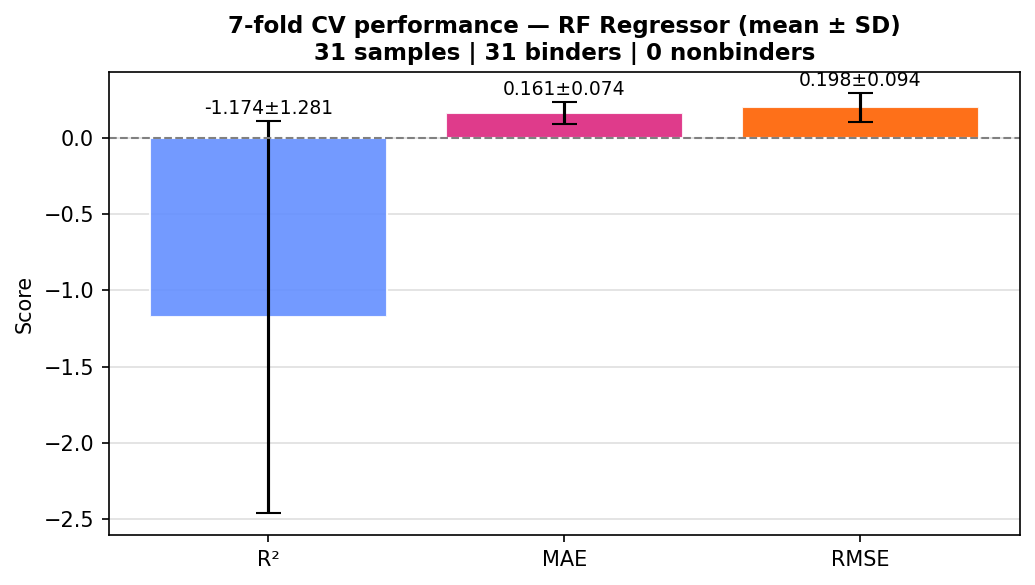

In [9]:
# -------------------------------------------------------------------
# Figure 1: CV metric summary (mean ± SD)
# -------------------------------------------------------------------
metric_labels = ["R²", "MAE", "RMSE"]
means = [r2_scores.mean(), mae_scores.mean(), rmse_scores.mean()]
sds   = [r2_scores.std(),  mae_scores.std(),  rmse_scores.std()]

fig1, ax1 = plt.subplots(figsize=(7, 4), dpi=150)
colors = ["#648FFF", "#DC267F", "#FE6100"]
bars = ax1.bar(metric_labels, means, yerr=sds, capsize=6,
               color=colors, edgecolor="white", alpha=0.9)

for bar, m, s in zip(bars, means, sds):
    ax1.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + s + 0.02,
             f"{m:.3f}±{s:.3f}", ha="center", va="bottom", fontsize=9)

ax1.set_ylabel("Score", fontsize=10)
ax1.set_ylim(bottom=min(0, min(means) - max(sds) - 0.15))
ax1.set_title(
    f"{N_SPLITS}-fold CV performance — RF Regressor (mean ± SD)\n"
    f"{n_total} samples | {n_binders} binders | {n_nonbinders} nonbinders",
    fontsize=11, fontweight="bold"
)
ax1.axhline(0, color="gray", linestyle="--", lw=1)
ax1.grid(True, axis="y", alpha=0.4)
ax1.set_axisbelow(True)
plt.tight_layout()
plt.show()

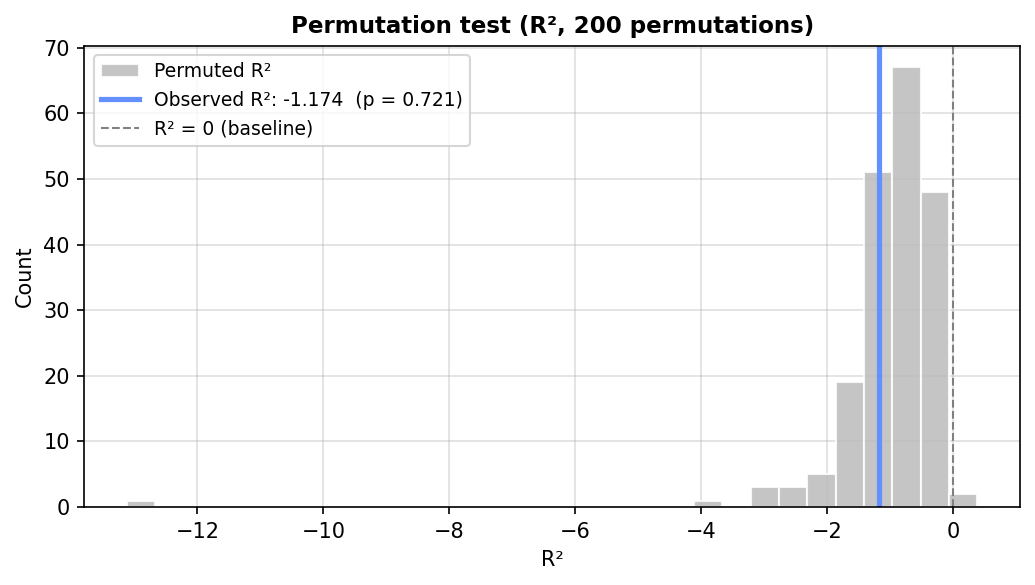

In [10]:
# -------------------------------------------------------------------
# Figure 2: Permutation test distribution
# -------------------------------------------------------------------
fig2, ax2 = plt.subplots(figsize=(7, 4), dpi=150)
ax2.hist(perm_scores, bins=30, color="#BBBBBB", edgecolor="white", alpha=0.85,
         label="Permuted R²")
ax2.axvline(obs_score, color="#648FFF", lw=2.5,
            label=f"Observed R²: {obs_score:.3f}  (p = {pval:.3f})")
ax2.axvline(0, color="gray", linestyle="--", lw=1, label="R² = 0 (baseline)")
ax2.set_xlabel("R²", fontsize=10)
ax2.set_ylabel("Count", fontsize=10)
ax2.set_title("Permutation test (R², 200 permutations)", fontsize=11, fontweight="bold")
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.4)
ax2.set_axisbelow(True)
plt.tight_layout()
plt.show()

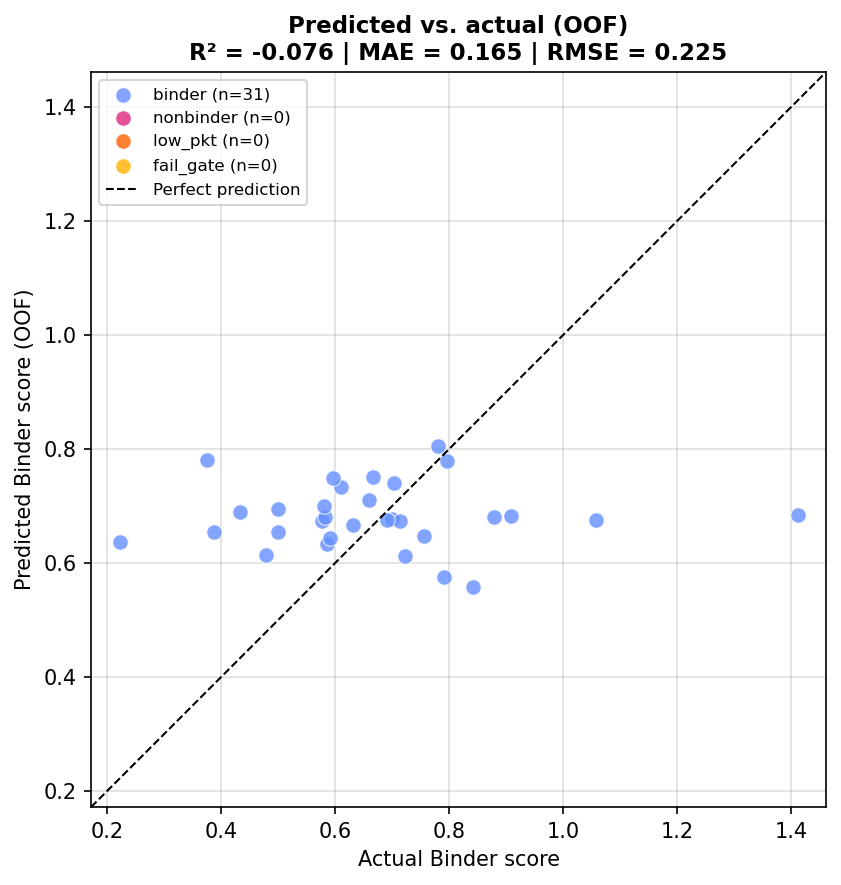

In [11]:
# -------------------------------------------------------------------
# Figure 3: Predicted vs. actual (OOF) — coloured by group
# -------------------------------------------------------------------
groups = df_reg["Group"].values
groups_unique = ["binder", "nonbinder", "low_pkt", "fail_gate"]

fig3, ax3 = plt.subplots(figsize=(6, 6), dpi=150)
for grp in groups_unique:
    mask = groups == grp
    ax3.scatter(
        y[mask], y_pred_cv[mask],
        color=GROUP_COLORS.get(grp, "gray"),
        alpha=0.8, s=55, edgecolors="white", linewidths=0.5,
        label=f"{grp} (n={mask.sum()})"
    )

lims = [min(y.min(), y_pred_cv.min()) - 0.05,
        max(y.max(), y_pred_cv.max()) + 0.05]
ax3.plot(lims, lims, "k--", lw=1, label="Perfect prediction")
ax3.set_xlim(lims)
ax3.set_ylim(lims)
ax3.set_xlabel("Actual Binder score", fontsize=10)
ax3.set_ylabel("Predicted Binder score (OOF)", fontsize=10)
ax3.set_title(
    f"Predicted vs. actual (OOF)\nR² = {r2_oof:.3f} | MAE = {mae_oof:.3f} | RMSE = {rmse_oof:.3f}",
    fontsize=11, fontweight="bold"
)
ax3.legend(fontsize=8, loc="upper left")
ax3.grid(True, alpha=0.4)
ax3.set_axisbelow(True)
ax3.set_aspect("equal")
plt.tight_layout()
plt.show()

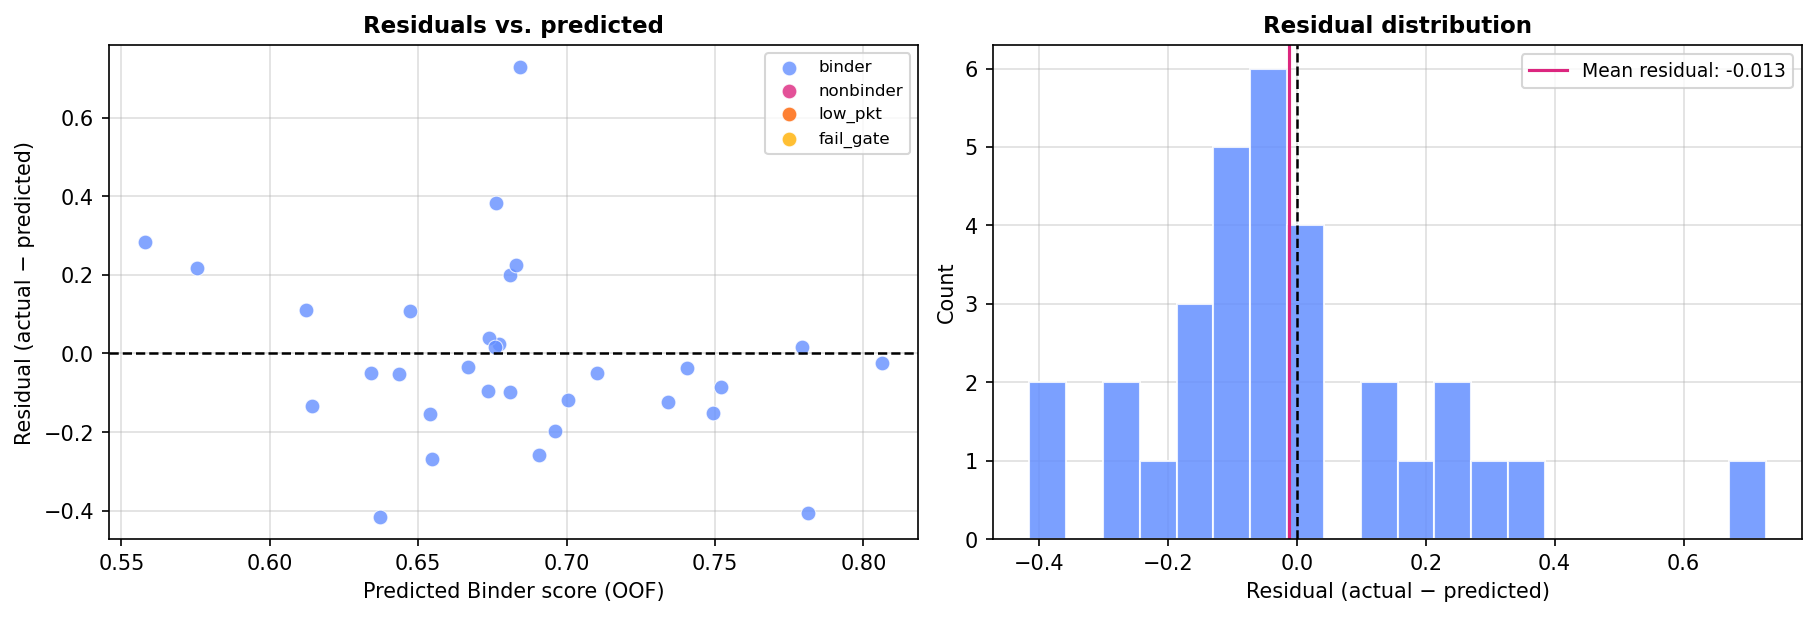

In [12]:
# -------------------------------------------------------------------
# Figure 4: Residual plots
# -------------------------------------------------------------------
residuals = y - y_pred_cv

fig4, axes4 = plt.subplots(1, 2, figsize=(12, 4), dpi=150, constrained_layout=True)

# Residuals vs predicted
ax = axes4[0]
for grp in groups_unique:
    mask = groups == grp
    ax.scatter(y_pred_cv[mask], residuals[mask],
               color=GROUP_COLORS.get(grp, "gray"),
               alpha=0.8, s=50, edgecolors="white", linewidths=0.5,
               label=grp)
ax.axhline(0, color="black", lw=1.2, linestyle="--")
ax.set_xlabel("Predicted Binder score (OOF)", fontsize=10)
ax.set_ylabel("Residual (actual − predicted)", fontsize=10)
ax.set_title("Residuals vs. predicted", fontsize=11, fontweight="bold")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.4)
ax.set_axisbelow(True)

# Residual histogram
ax2 = axes4[1]
ax2.hist(residuals, bins=20, color="#648FFF", edgecolor="white", alpha=0.85)
ax2.axvline(0, color="black", lw=1.2, linestyle="--")
ax2.axvline(residuals.mean(), color="#DC267F", lw=1.5, linestyle="-",
            label=f"Mean residual: {residuals.mean():.3f}")
ax2.set_xlabel("Residual (actual − predicted)", fontsize=10)
ax2.set_ylabel("Count", fontsize=10)
ax2.set_title("Residual distribution", fontsize=11, fontweight="bold")
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.4)
ax2.set_axisbelow(True)

plt.show()

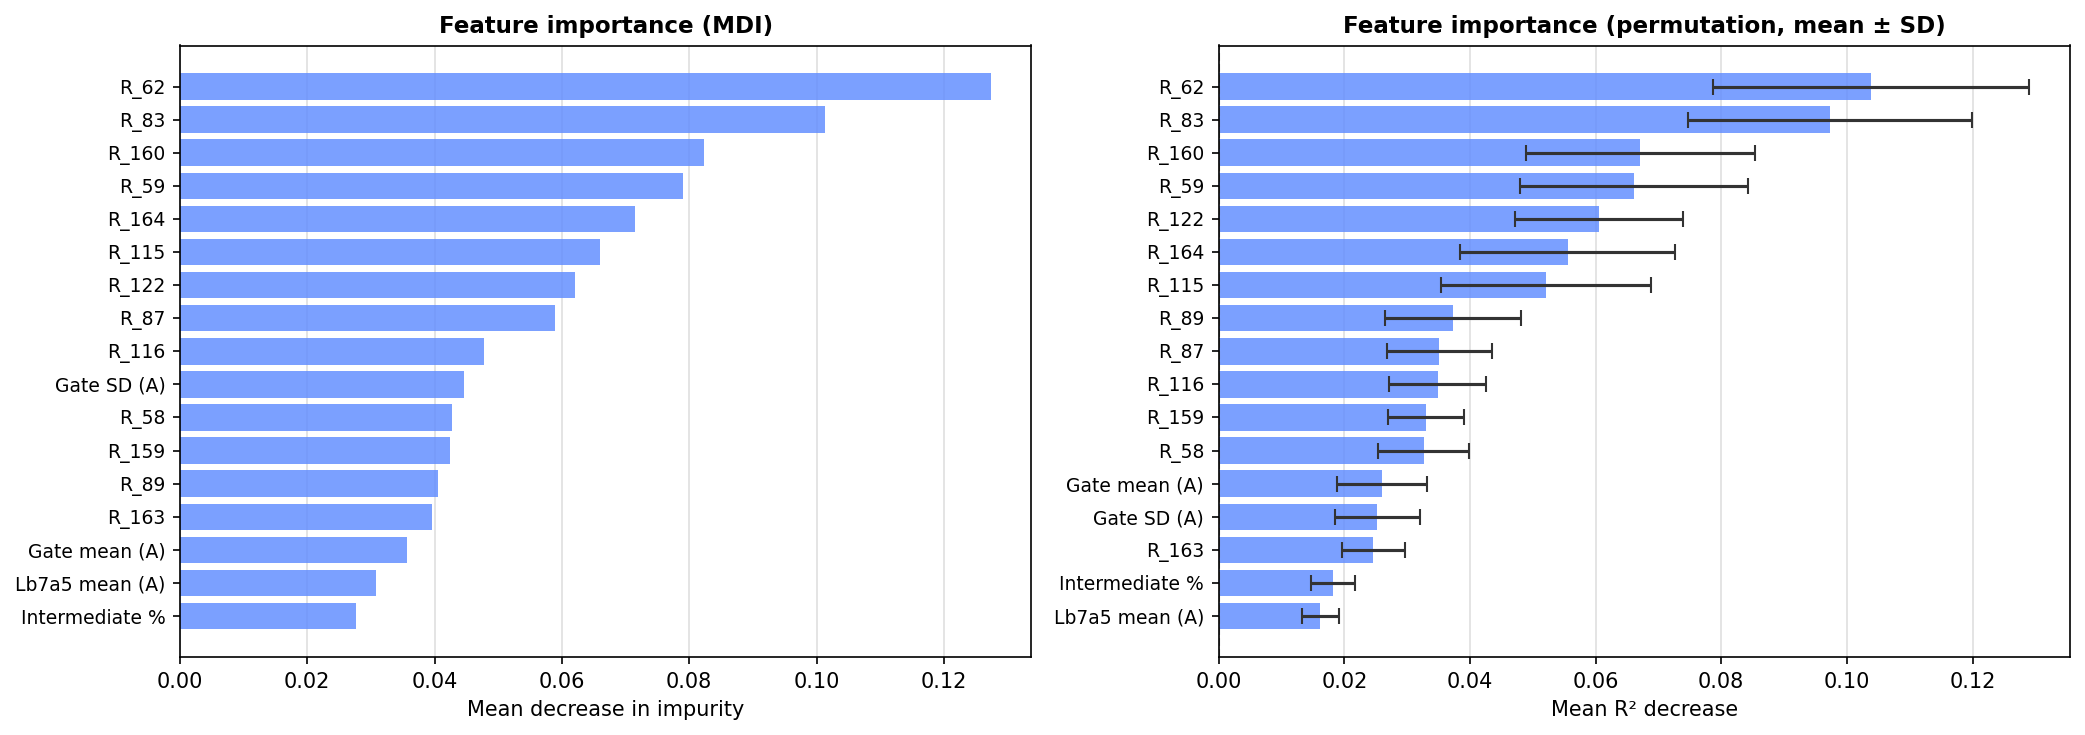

In [13]:
# -------------------------------------------------------------------
# Figure 5: Feature importance — MDI + permutation (full-data fit)
# -------------------------------------------------------------------
mdi_imp  = rf.feature_importances_
perm_imp = permutation_importance(
    rf, X, y, n_repeats=30, random_state=42, n_jobs=1
)

sorted_idx      = np.argsort(mdi_imp)
feat_names_mdi  = [feature_cols[i] for i in sorted_idx]

perm_sorted_idx  = np.argsort(perm_imp.importances_mean)
feat_names_perm  = [feature_cols[i] for i in perm_sorted_idx]

fig5, axes5 = plt.subplots(1, 2, figsize=(14, 5), dpi=150)

axes5[0].barh(range(len(sorted_idx)), mdi_imp[sorted_idx],
              color="#648FFF", alpha=0.85)
axes5[0].set_yticks(range(len(sorted_idx)))
axes5[0].set_yticklabels(feat_names_mdi, fontsize=9)
axes5[0].set_xlabel("Mean decrease in impurity", fontsize=10)
axes5[0].set_title("Feature importance (MDI)", fontsize=11, fontweight="bold")
axes5[0].grid(True, axis="x", alpha=0.4)
axes5[0].set_axisbelow(True)

axes5[1].barh(
    range(len(perm_sorted_idx)),
    perm_imp.importances_mean[perm_sorted_idx],
    xerr=perm_imp.importances_std[perm_sorted_idx],
    capsize=4, color="#648FFF", alpha=0.85, ecolor="#333333"
)
axes5[1].set_yticks(range(len(perm_sorted_idx)))
axes5[1].set_yticklabels(feat_names_perm, fontsize=9)
axes5[1].set_xlabel("Mean R² decrease", fontsize=10)
axes5[1].set_title("Feature importance (permutation, mean ± SD)",
                   fontsize=11, fontweight="bold")
axes5[1].axvline(0, color="gray", linestyle="--", lw=1)
axes5[1].grid(True, axis="x", alpha=0.4)
axes5[1].set_axisbelow(True)

plt.tight_layout()
plt.show()

In [14]:
# -------------------------------------------------------------------
# Summary table
# -------------------------------------------------------------------
summary = pd.DataFrame({
    "Metric":  ["R²",            "MAE",          "RMSE"],
    "CV mean": [r2_scores.mean(),mae_scores.mean(),rmse_scores.mean()],
    "CV SD":   [r2_scores.std(), mae_scores.std(), rmse_scores.std()],
    "OOF":     [r2_oof,          mae_oof,          rmse_oof],
}).round(4)
print(summary.to_string(index=False))
print()
print(f"Permutation test  |  Observed R²: {obs_score:.3f}  |  p-value: {pval:.3f}")
print()
print("Feature importances (MDI, descending):")
imp_df = pd.DataFrame({
    "Feature": feature_cols,
    "MDI":     rf.feature_importances_,
    "Perm mean": perm_imp.importances_mean,
    "Perm SD":   perm_imp.importances_std,
}).sort_values("MDI", ascending=False).round(4)
print(imp_df.to_string(index=False))

Metric  CV mean  CV SD     OOF
    R²  -1.1738 1.2813 -0.0756
   MAE   0.1612 0.0739  0.1646
  RMSE   0.1979 0.0938  0.2247

Permutation test  |  Observed R²: -1.174  |  p-value: 0.721

Feature importances (MDI, descending):
       Feature    MDI  Perm mean  Perm SD
          R_62 0.1273     0.1038   0.0252
          R_83 0.1013     0.0973   0.0226
         R_160 0.0823     0.0671   0.0182
          R_59 0.0789     0.0661   0.0182
         R_164 0.0715     0.0555   0.0171
         R_115 0.0660     0.0521   0.0167
         R_122 0.0620     0.0606   0.0134
          R_87 0.0589     0.0351   0.0083
         R_116 0.0477     0.0349   0.0077
   Gate SD (A) 0.0446     0.0252   0.0067
          R_58 0.0427     0.0326   0.0072
         R_159 0.0424     0.0330   0.0060
          R_89 0.0406     0.0373   0.0108
         R_163 0.0396     0.0246   0.0050
 Gate mean (A) 0.0357     0.0260   0.0072
Lb7a5 mean (A) 0.0307     0.0162   0.0029
Intermediate % 0.0277     0.0183   0.0035
